# Mini Project: Medical Insurance Cost Prediction
**Objective:** Can you accurately predict medical insurance costs based on patient data? In this project, you’ll build various regression models and compare their performance to recommend the best one to the stakeholders.

---
## Task 1: Import Libraries & Load Data

In [1]:

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, ConfusionMatrixDisplay
)
from scipy import stats

In [2]:
df = pd.read_csv("Medical Insurance.csv")

print("Dataset Shape:", df.shape)
print("\n--- First 5 Rows ---")
df.head()

Dataset Shape: (1338, 7)

--- First 5 Rows ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print("--- Dataset Info ---")
df.info()

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
print("--- Descriptive Statistics ---")
df.describe().T

--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [5]:
# Shape

print("Shape :",df.shape)

# Information

print(df.info())

# Statistical summary

print(df.describe())

# Check null values

print(df.isnull().sum())

Shape : (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515


---
## Task 2: Exploratory Data Analysis (EDA)

In [6]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


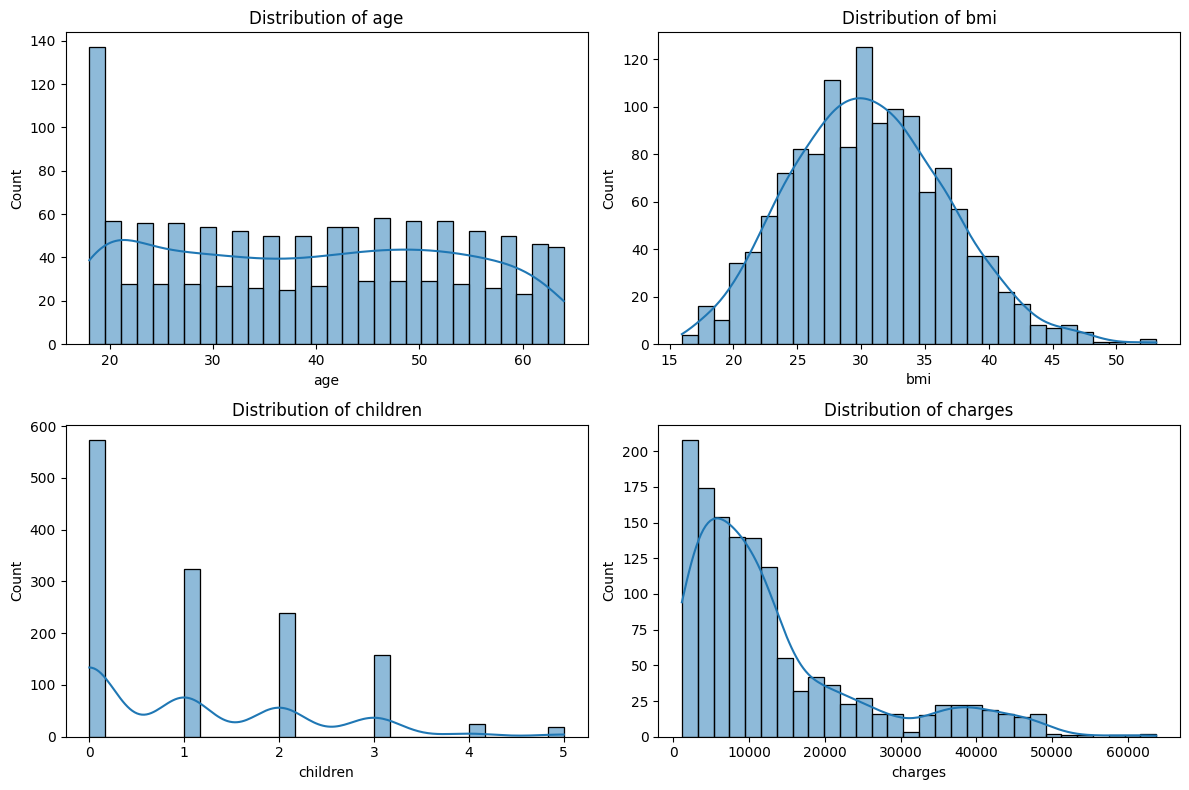

In [7]:
num_cols = ['age','bmi','children','charges']

plt.figure(figsize=(12,8))

for i,col in enumerate(num_cols):

    plt.subplot(2,2,i+1)

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f'Distribution of {col}')

plt.tight_layout()

plt.show()

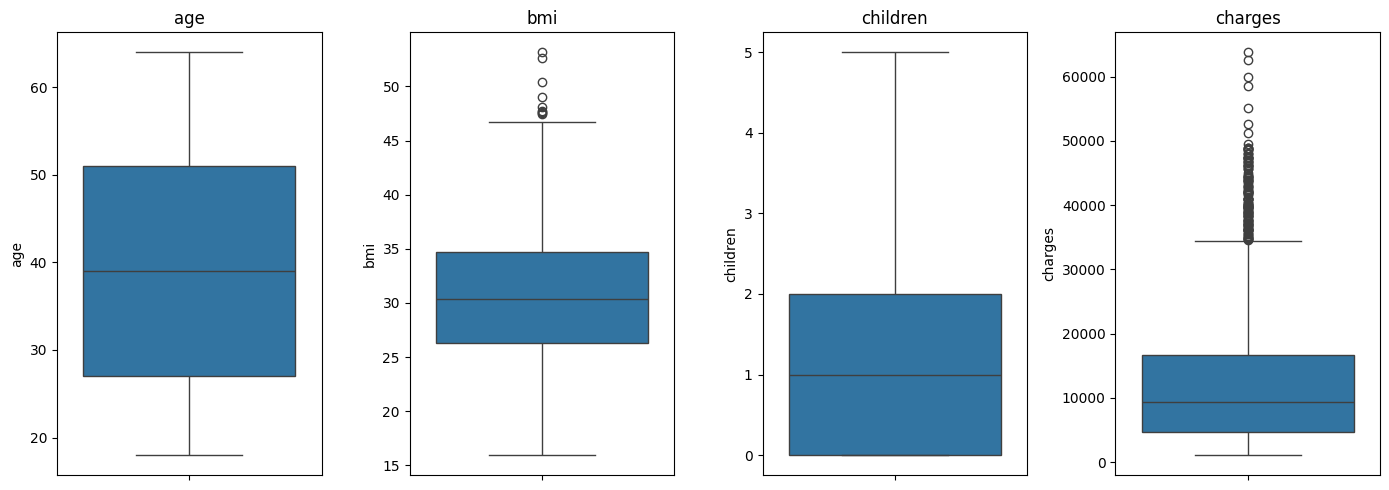

In [8]:
plt.figure(figsize=(14,5))

for i,col in enumerate(num_cols):

    plt.subplot(1,4,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

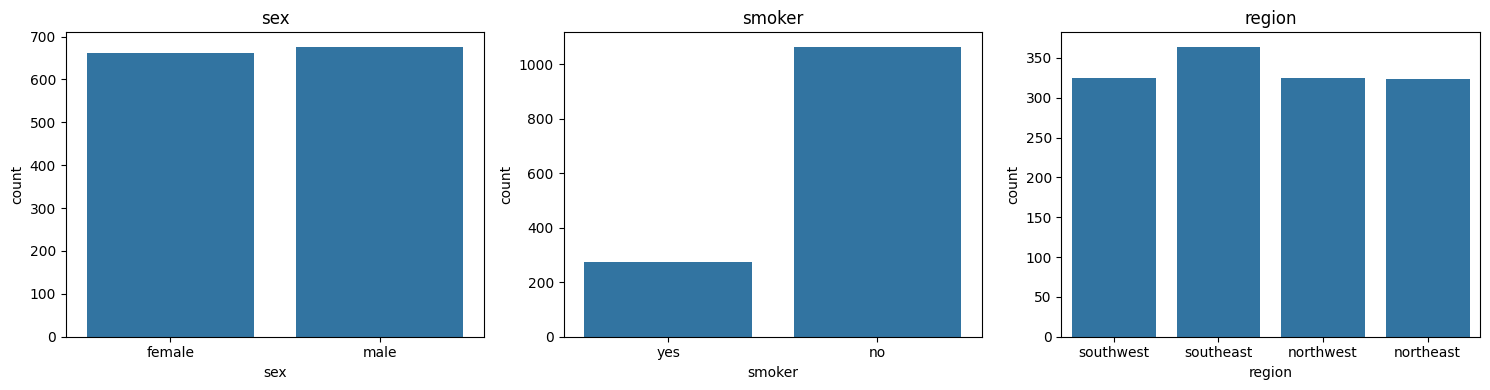

In [9]:
cat_cols=['sex','smoker','region']

plt.figure(figsize=(15,4))

for i,col in enumerate(cat_cols):

    plt.subplot(1,3,i+1)

    sns.countplot(
        x=df[col]
    )

    plt.title(col)

plt.tight_layout()

plt.show()

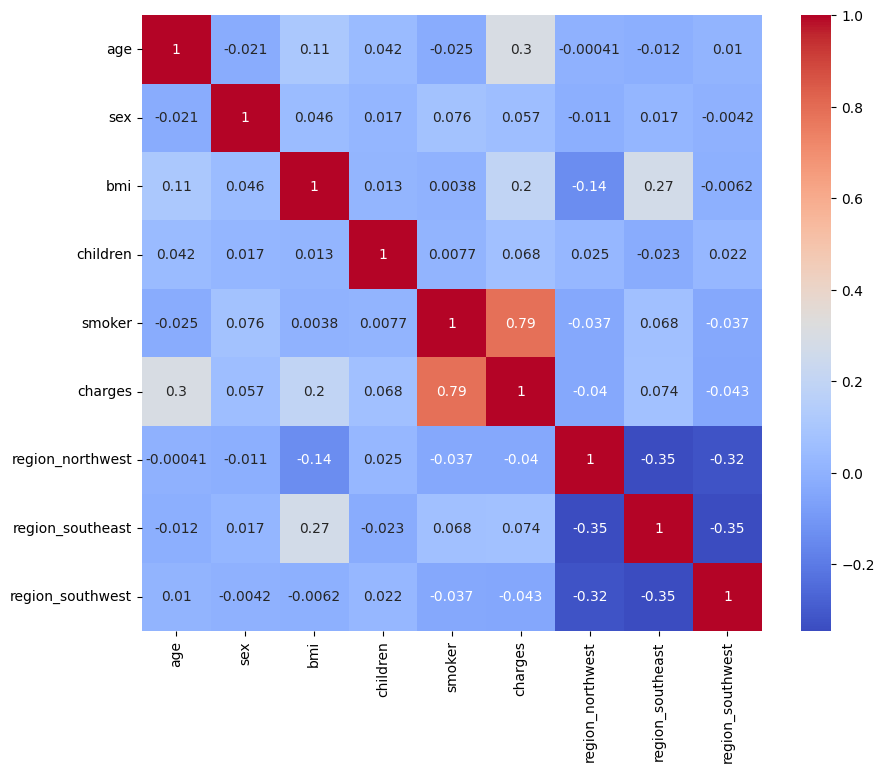

In [10]:
temp=df.copy()

temp['sex']=temp['sex'].map({'male':1,'female':0})

temp['smoker']=temp['smoker'].map({'yes':1,'no':0})

temp=pd.get_dummies(temp,columns=['region'],drop_first=True)

plt.figure(figsize=(10,8))

sns.heatmap(temp.corr(),annot=True,cmap='coolwarm')

plt.show()

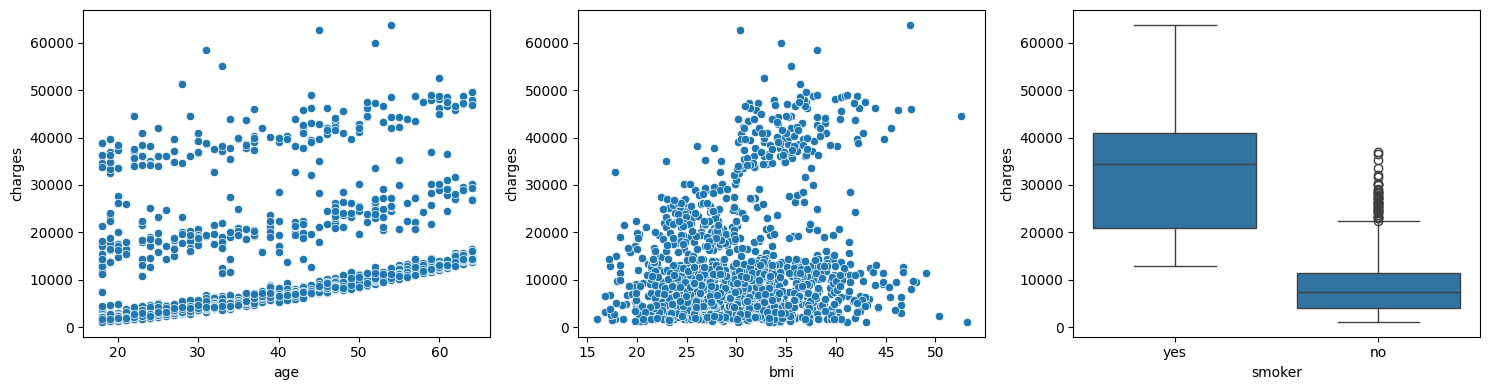

In [11]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.scatterplot(x='age',y='charges',data=df)

plt.subplot(1,3,2)
sns.scatterplot(x='bmi',y='charges',data=df)

plt.subplot(1,3,3)
sns.boxplot(x='smoker',y='charges',data=df)

plt.tight_layout()

plt.show()

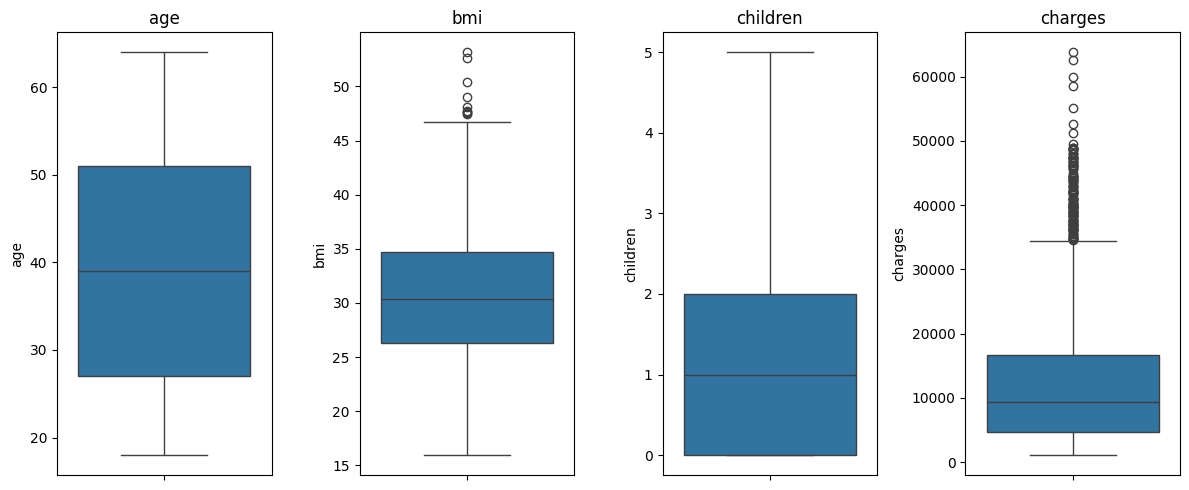

In [12]:
plt.figure(figsize=(12,5))

for i,col in enumerate(num_cols):

    plt.subplot(1,4,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [13]:
# Numerical columns

num_cols=['age','bmi','children','charges']

for col in num_cols:

    Q1=df[col].quantile(0.25)

    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    outliers=df[
        (df[col]<lower)|
        (df[col]>upper)
    ].shape[0]

    print(col,"Outliers =",outliers)

age Outliers = 0
bmi Outliers = 9
children Outliers = 0
charges Outliers = 139


In [14]:
df['charges']=np.log1p(df['charges'])

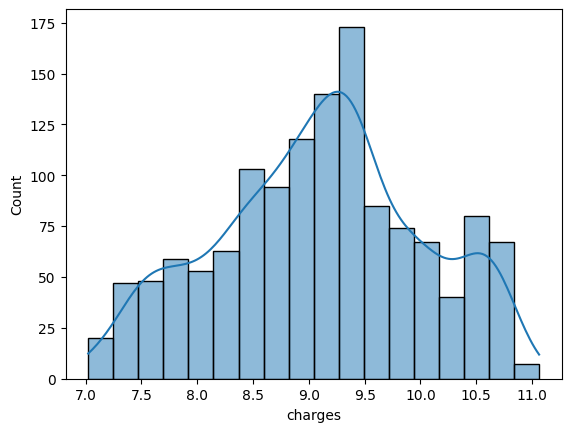

In [15]:
sns.histplot(df['charges'],kde=True)

plt.show()

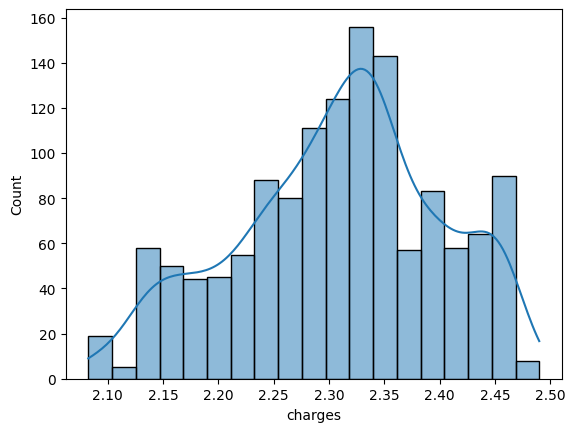

In [16]:
df['charges']=np.log1p(df['charges'])

sns.histplot(df['charges'],kde=True)

plt.show()

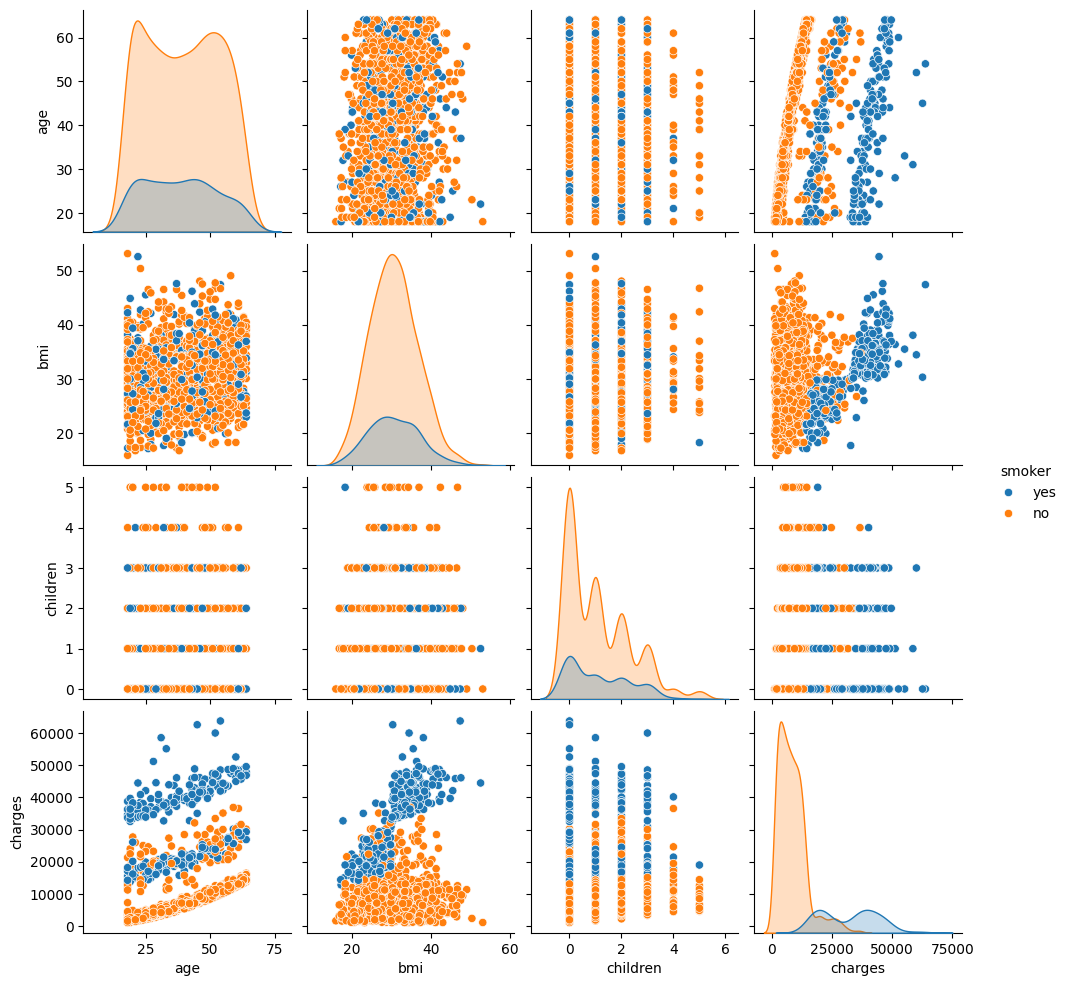

In [17]:
# Load original data again or use before get_dummies was applied
df_original = pd.read_csv("Medical Insurance.csv")

sns.pairplot(
    df_original,
    hue='smoker'
)

plt.show()

In [18]:
print(df[['age','bmi','children','charges']].skew())

age         0.055673
bmi         0.284047
children    0.938380
charges    -0.278478
dtype: float64


In [19]:
print("Dataset Shape :",df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nData Types")
print(df.dtypes)

print("\nSkewness")
print(df[['age','bmi','children','charges']].skew())

Dataset Shape : (1338, 7)

Missing Values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data Types
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Skewness
age         0.055673
bmi         0.284047
children    0.938380
charges    -0.278478
dtype: float64


In [20]:
df=pd.get_dummies(df,drop_first=True)

df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,2.373438,False,True,False,False,True
1,18,33.770,1,2.134626,True,False,False,True,False
2,28,33.000,3,2.240791,True,False,False,True,False
3,33,22.705,0,2.397726,True,False,True,False,False
4,32,28.880,0,2.225753,True,False,True,False,False


In [21]:
X=df.drop('charges',axis=1)

y=df['charges']

In [22]:
# 4. Feature Engineering & Preprocessing
# Numerical Features

num_cols = ['age','bmi','children']

# Categorical Features

cat_cols = ['sex','smoker','region']

print("Numerical Features :",num_cols)
print("Categorical Features :",cat_cols)    


Numerical Features : ['age', 'bmi', 'children']
Categorical Features : ['sex', 'smoker', 'region']


In [23]:
# Check skewness

print(df[['age','bmi','children','charges']].skew())

age         0.055673
bmi         0.284047
children    0.938380
charges    -0.278478
dtype: float64


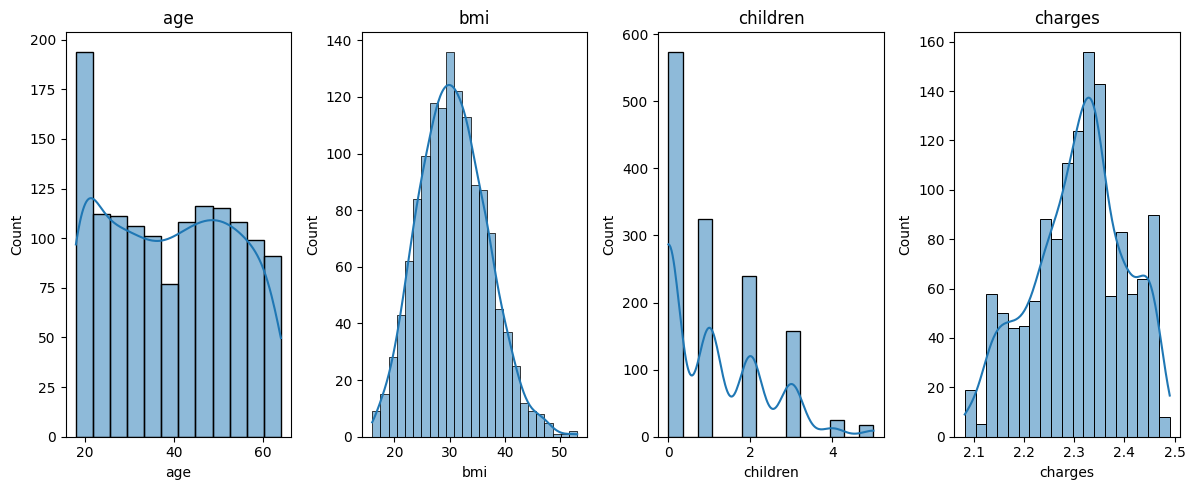

In [24]:
plt.figure(figsize=(12,5))

for i,col in enumerate(['age','bmi','children','charges']):

    plt.subplot(1,4,i+1)

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

plt.tight_layout()

plt.show()

In [25]:
# Log transformation

df['charges'] = np.log1p(
    df['charges']
)

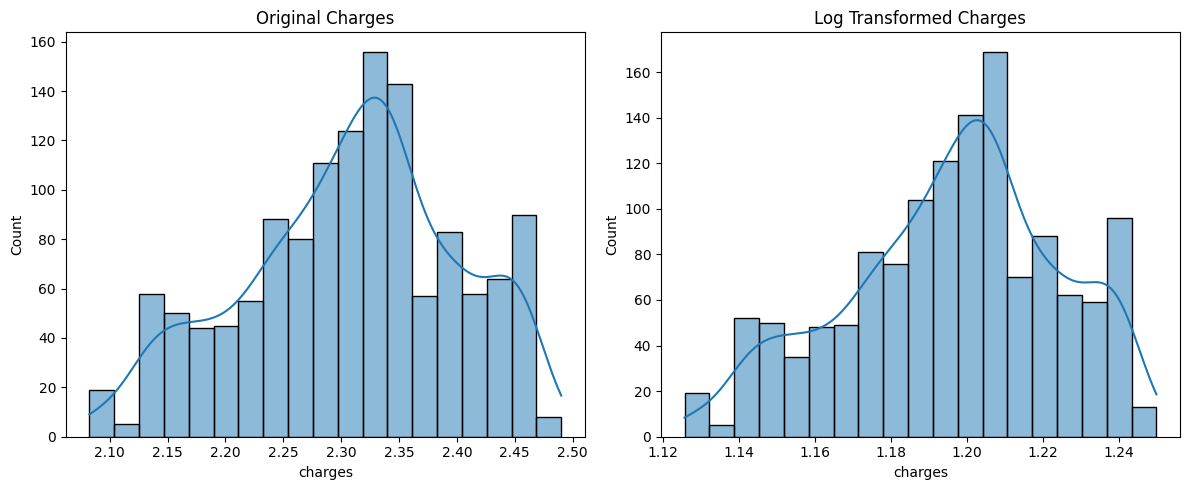

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    np.expm1(df['charges']),
    kde=True
)

plt.title("Original Charges")

plt.subplot(1,2,2)

sns.histplot(
    df['charges'],
    kde=True
)

plt.title("Log Transformed Charges")

plt.tight_layout()

plt.show()

In [27]:
X = df.drop(
    'charges',
    axis=1
)

y = df['charges']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

print("Training Shape :",X_train.shape)
print("Testing Shape :",X_test.shape)

Training Shape : (1070, 8)
Testing Shape : (268, 8)


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform( X_train)

X_test_scaled=scaler.transform(X_test)

In [31]:
scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1070.0,-1.992176e-16,1.000468,-1.518194,-0.878416,0.010165,0.827659,1.751782
bmi,1070.0,-4.648410e-17,1.000468,-2.417060,-0.721025,-0.058007,0.651571,3.736342
children,1070.0,-2.324205e-17,1.000468,-0.911192,-0.911192,-0.088428,0.734336,3.202629
sex_male,1070.0,-6.308557e-17,1.000468,-1.024602,-1.024602,0.975989,0.975989,0.975989
smoker_yes,1070.0,2.988264e-17,1.000468,-0.508747,-0.508747,-0.508747,-0.508747,1.965613
region_northwest,1070.0,-4.648410e-17,1.000468,-0.560800,-0.560800,-0.560800,-0.560800,1.783168
region_southeast,1070.0,-3.320293e-17,1.000468,-0.599661,-0.599661,-0.599661,1.667609,1.667609
region_southwest,1070.0,7.304645e-17,1.000468,-0.572314,-0.572314,-0.572314,-0.572314,1.747292


In [32]:
# Encode

df = pd.get_dummies(
    df,
    drop_first=True
)

# Log Transform Target

df['charges'] = np.log1p(
    df['charges']
)

# Split

X = df.drop('charges',axis=1)

y = df['charges']

X_train,X_test,y_train,y_test = train_test_split(

    X,y,

    test_size=0.20,

    random_state=42
)

# Scale

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [33]:
#5. Model Building: Try Multiple Regressors

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
y_train_pred_lr = lr.predict(
    X_train_scaled
)

y_test_pred_lr = lr.predict(
    X_test_scaled
)

In [35]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

train_mae = mean_absolute_error(
    y_train,
    y_train_pred_lr
)

train_mse = mean_squared_error(
    y_train,
    y_train_pred_lr
)

train_rmse = np.sqrt(
    train_mse
)

train_r2 = r2_score(
    y_train,
    y_train_pred_lr
)

print("Train MAE :",train_mae)
print("Train RMSE :",train_rmse)
print("Train R2 :",train_r2)

Train MAE : 0.004019799636147869
Train RMSE : 0.006403806210719044
Train R2 : 0.7440999790511872


In [36]:
test_mae = mean_absolute_error(
    y_test,
    y_test_pred_lr
)

test_mse = mean_squared_error(
    y_test,
    y_test_pred_lr
)

test_rmse = np.sqrt(
    test_mse
)

test_r2 = r2_score(
    y_test,
    y_test_pred_lr
)

print("Test MAE :",test_mae)
print("Test RMSE :",test_rmse)
print("Test R2 :",test_r2)

Test MAE : 0.0037765046388614177
Test RMSE : 0.005979649607811881
Test R2 : 0.7935996421533564


In [37]:
n = X_test.shape[0]

p = X_test.shape[1]

adj_r2 = 1 - ((1-test_r2)*(n-1))/(n-p-1)

print("Adjusted R2 :",adj_r2)

Adjusted R2 : 0.7872243415248887


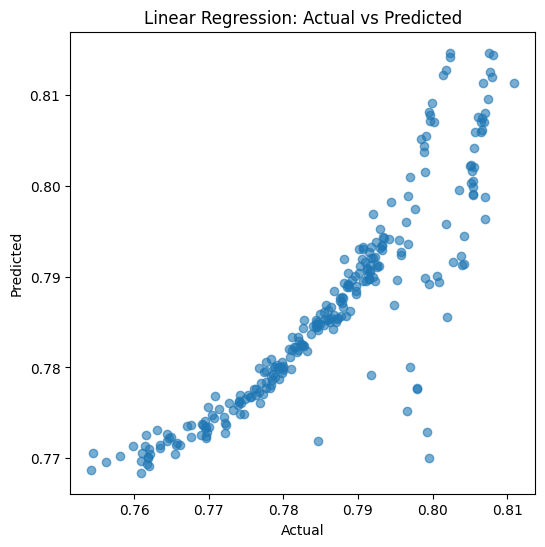

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred_lr,
    alpha=0.6
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Linear Regression: Actual vs Predicted"
)

plt.show()

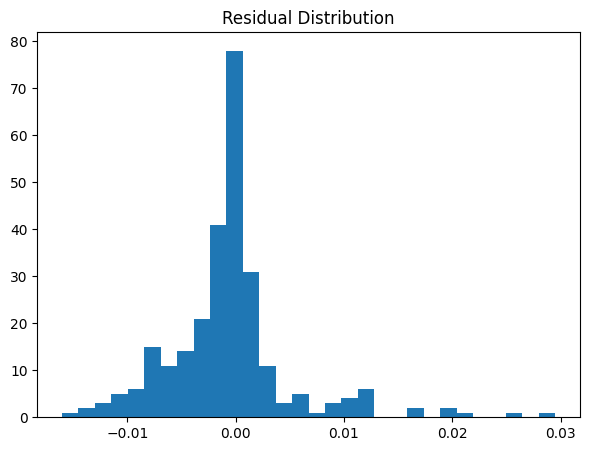

In [39]:
residuals = y_test - y_test_pred_lr

plt.figure(figsize=(7,5))

plt.hist(
    residuals,
    bins=30
)

plt.title(
    "Residual Distribution"
)

plt.show()

In [40]:
lr_train_rmse = train_rmse
lr_test_rmse = test_rmse

lr_train_r2 = train_r2
lr_test_r2 = test_r2

In [41]:
print("Train MAE :",train_mae)
print("Train RMSE :",train_rmse)
print("Train R2 :",train_r2)
print("Test MAE :",test_mae)
print("Test RMSE :",test_rmse)
print("Test R2 :",test_r2)

Train MAE : 0.004019799636147869
Train RMSE : 0.006403806210719044
Train R2 : 0.7440999790511872
Test MAE : 0.0037765046388614177
Test RMSE : 0.005979649607811881
Test R2 : 0.7935996421533564


In [42]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [43]:
y_train_pred_dt = dt.predict(
    X_train
)

y_test_pred_dt = dt.predict(
    X_test
)

In [44]:
train_mae = mean_absolute_error(
    y_train,
    y_train_pred_dt
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_dt
    )
)

train_r2 = r2_score(
    y_train,
    y_train_pred_dt
)

print("Train MAE :",train_mae)
print("Train RMSE :",train_rmse)
print("Train R2 :",train_r2)

Train MAE : 6.0557225291514024e-05
Train RMSE : 0.0009904401050469618
Train R2 : 0.993878605140146


In [45]:
test_mae = mean_absolute_error(
    y_test,
    y_test_pred_dt
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_dt
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred_dt
)

print("Test MAE :",test_mae)
print("Test RMSE :",test_rmse)
print("Test R2 :",test_r2)

Test MAE : 0.0029591667355107995
Test RMSE : 0.00691624789828417
Test R2 : 0.72387859406146


In [46]:
print("Test MAE :",test_mae)
print("Test RMSE :",test_rmse)
print("Test R2 :",test_r2)
print("Train MAE :",train_mae)
print("Train RMSE :",train_rmse)
print("Train R2 :",train_r2)

Test MAE : 0.0029591667355107995
Test RMSE : 0.00691624789828417
Test R2 : 0.72387859406146
Train MAE : 6.0557225291514024e-05
Train RMSE : 0.0009904401050469618
Train R2 : 0.993878605140146


In [47]:
n = X_test.shape[0]

p = X_test.shape[1]

adj_r2 = 1 - ((1-test_r2)*(n-1))/(n-p-1)

print("Adjusted R2 :",adj_r2)

Adjusted R2 : 0.7153497475459839


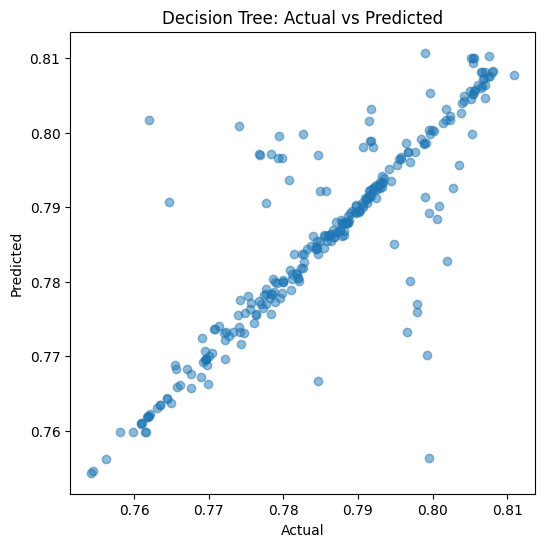

In [48]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred_dt,
    alpha=0.5
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title(
    "Decision Tree: Actual vs Predicted"
)

plt.show()

In [49]:
dt_train_rmse = train_rmse
dt_test_rmse = test_rmse

dt_train_r2 = train_r2
dt_test_r2 = test_r2

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [51]:
y_train_pred_rf = rf.predict(
    X_train
)

y_test_pred_rf = rf.predict(
    X_test
)

In [52]:
train_mae = mean_absolute_error(
    y_train,
    y_train_pred_rf
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_rf
    )
)

train_r2 = r2_score(
    y_train,
    y_train_pred_rf
)

print("Train MAE :",train_mae)
print("Train RMSE :",train_rmse)
print("Train R2 :",train_r2)

Train MAE : 0.001105917249816162
Train RMSE : 0.0022440611383505262
Train R2 : 0.9685758651934118


In [53]:
test_mae = mean_absolute_error(
    y_test,
    y_test_pred_rf
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_rf
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred_rf
)

print("Test MAE :",test_mae)
print("Test RMSE :",test_rmse)
print("Test R2 :",test_r2)

Test MAE : 0.002631215630277181
Test RMSE : 0.005152982357834392
Test R2 : 0.8467232494999749


In [54]:
print("Test MAE :",test_mae)
print("Test RMSE :",test_rmse)
print("Test R2 :",test_r2)
print("Train MAE :",train_mae)
print("Train RMSE :",train_rmse)
print("Train R2 :",train_r2)

Test MAE : 0.002631215630277181
Test RMSE : 0.005152982357834392
Test R2 : 0.8467232494999749
Train MAE : 0.001105917249816162
Train RMSE : 0.0022440611383505262
Train R2 : 0.9685758651934118


In [55]:
n = X_test.shape[0]

p = X_test.shape[1]

adj_r2 = 1 - ((1-test_r2)*(n-1))/(n-p-1)

print("Adjusted R2 :",adj_r2)

Adjusted R2 : 0.8419888324961131


In [56]:
importance = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

            Feature  Importance
0               age    0.430212
4        smoker_yes    0.389898
1               bmi    0.092801
2          children    0.047577
3          sex_male    0.014087
6  region_southeast    0.009465
5  region_northwest    0.008618
7  region_southwest    0.007342


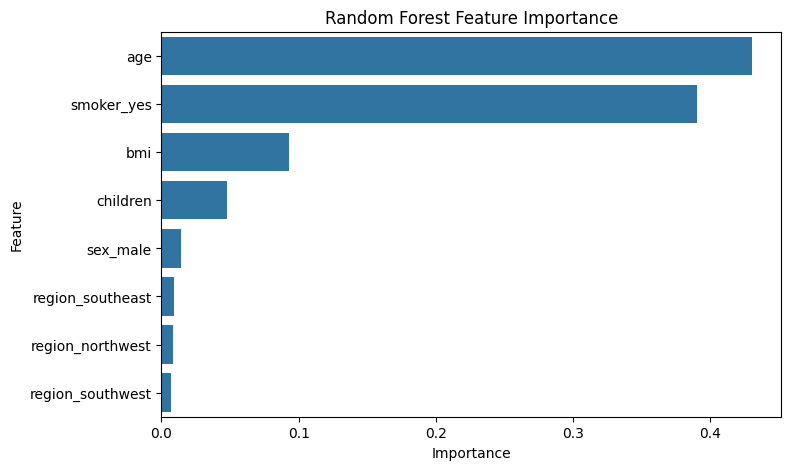

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance

)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

In [58]:
rf_train_rmse = 0.00224
rf_test_rmse = 0.00515

rf_train_r2 = 0.9686
rf_test_r2 = 0.8467

In [59]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [60]:
y_train_pred_knn = knn.predict(
    X_train_scaled
)

y_test_pred_knn = knn.predict(
    X_test_scaled
)

In [61]:
train_mae = mean_absolute_error(
    y_train,
    y_train_pred_knn
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_knn
    )
)

train_r2 = r2_score(
    y_train,
    y_train_pred_knn
)

print("Train MAE :",train_mae)
print("Train RMSE :",train_rmse)
print("Train R2 :",train_r2)

Train MAE : 0.002865381416400058
Train RMSE : 0.00482650592868668
Train R2 : 0.8546350686878288


In [62]:
test_mae = mean_absolute_error(
    y_test,
    y_test_pred_knn
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_knn
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred_knn
)

print("Test MAE :",test_mae)
print("Test RMSE :",test_rmse)
print("Test R2 :",test_r2)

Test MAE : 0.0036219179350324704
Test RMSE : 0.005842633340462378
Test R2 : 0.8029500909204067


In [63]:
print("Test MAE :",test_mae)
print("Test RMSE :",test_rmse)
print("Test R2 :",test_r2)
print("Train MAE :",train_mae)
print("Train RMSE :",train_rmse)
print("Train R2 :",train_r2)

Test MAE : 0.0036219179350324704
Test RMSE : 0.005842633340462378
Test R2 : 0.8029500909204067
Train MAE : 0.002865381416400058
Train RMSE : 0.00482650592868668
Train R2 : 0.8546350686878288


In [64]:
n = X_test.shape[0]

p = X_test.shape[1]

adj_r2 = 1 - ((1-test_r2)*(n-1))/(n-p-1)

print("Adjusted R2 :",adj_r2)

Adjusted R2 : 0.7968636072422726


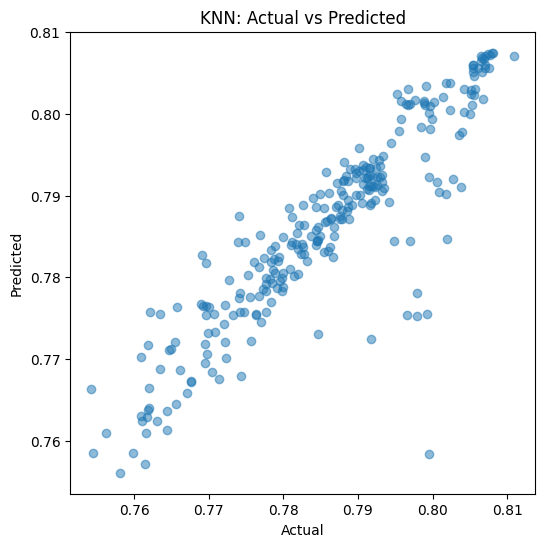

In [65]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred_knn,
    alpha=0.5
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title(
    "KNN: Actual vs Predicted"
)

plt.show()

In [66]:
from sklearn.svm import SVR

svr = SVR(
    kernel='rbf'
)

svr.fit(
    X_train_scaled,
    y_train
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [67]:
y_train_pred_svr = svr.predict(
    X_train_scaled
)

y_test_pred_svr = svr.predict(
    X_test_scaled
)

In [68]:
train_mae = mean_absolute_error(
    y_train,
    y_train_pred_svr
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_svr
    )
)

train_r2 = r2_score(
    y_train,
    y_train_pred_svr
)

print("Train MAE :",train_mae)
print("Train RMSE :",train_rmse)
print("Train R2 :",train_r2)

Train MAE : 0.011151410409201618
Train RMSE : 0.013393109328881651
Train R2 : -0.11932650435345238


In [69]:
test_mae = mean_absolute_error(
    y_test,
    y_test_pred_svr
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_svr
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred_svr
)

print("Test MAE :",test_mae)
print("Test RMSE :",test_rmse)
print("Test R2 :",test_r2)

Test MAE : 0.011290804858093095
Test RMSE : 0.013569642527561782
Test R2 : -0.06290827327965665


In [70]:
print("Test MAE :",test_mae)
print("Test RMSE :",test_rmse)
print("Test R2 :",test_r2)
print("Train MAE :",train_mae)
print("Train RMSE :",train_rmse)
print("Train R2 :",train_r2)

Test MAE : 0.011290804858093095
Test RMSE : 0.013569642527561782
Test R2 : -0.06290827327965665
Train MAE : 0.011151410409201618
Train RMSE : 0.013393109328881651
Train R2 : -0.11932650435345238


In [71]:
n = X_test.shape[0]

p = X_test.shape[1]

adj_r2 = 1 - ((1-test_r2)*(n-1))/(n-p-1)

print("Adjusted R2 :",adj_r2)

Adjusted R2 : -0.09573941685586229


In [72]:
svr_train_rmse = train_rmse
svr_test_rmse = test_rmse

svr_train_r2 = train_r2
svr_test_r2 = test_r2




In [73]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(
    n_estimators=200,
    random_state=42
)

ada.fit(
    X_train,
    y_train
)

y_train_pred_ada = ada.predict(X_train)
y_test_pred_ada = ada.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train,y_train_pred_ada))
test_rmse = np.sqrt(mean_squared_error(y_test,y_test_pred_ada))

train_r2 = r2_score(y_train,y_train_pred_ada)
test_r2 = r2_score(y_test,y_test_pred_ada)

print("Train RMSE :",train_rmse)
print("Test RMSE :",test_rmse)

print("Train R2 :",train_r2)
print("Test R2 :",test_r2)

Train RMSE : 0.006804306913051734
Test RMSE : 0.007429208469901166
Train R2 : 0.7110905493378288
Test R2 : 0.6814012526562615


In [74]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42
)

et.fit(
    X_train,
    y_train
)

y_train_pred_et = et.predict(X_train)
y_test_pred_et = et.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train,y_train_pred_et))
test_rmse = np.sqrt(mean_squared_error(y_test,y_test_pred_et))

train_r2 = r2_score(y_train,y_train_pred_et)
test_r2 = r2_score(y_test,y_test_pred_et)

print("Train RMSE :",train_rmse)
print("Test RMSE :",test_rmse)

print("Train R2 :",train_r2)
print("Test R2 :",test_r2)

Train RMSE : 0.0009904401050469616
Test RMSE : 0.005666390687458079
Train R2 : 0.993878605140146
Test R2 : 0.8146587858875727


In [75]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

y_train_pred_gb = gb.predict(X_train)
y_test_pred_gb = gb.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train,y_train_pred_gb))
test_rmse = np.sqrt(mean_squared_error(y_test,y_test_pred_gb))

train_r2 = r2_score(y_train,y_train_pred_gb)
test_r2 = r2_score(y_test,y_test_pred_gb)

print("Train RMSE :",train_rmse)
print("Test RMSE :",test_rmse)

print("Train R2 :",train_r2)
print("Test R2 :",test_r2)

Train RMSE : 0.004359729172770276
Test RMSE : 0.004767384476428438
Train R2 : 0.8813922731212904
Test R2 : 0.8688043820302063


In [76]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

r2 = r2_score(
    y_test,
    y_pred_xgb
)

print("RMSE :",rmse)
print("R2 :",r2)

RMSE : 0.004831158172594964
R2 : 0.8652708758046609


In [77]:
# 6. Model Evaluation & Overfitting Check
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

def evaluate_model(model,
                   X_train,
                   X_test,
                   y_train,
                   y_test):

    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(
        y_train,
        y_train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )

    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    train_rmse = np.sqrt(train_mse)

    test_rmse = np.sqrt(test_mse)

    train_r2 = r2_score(
        y_train,
        y_train_pred
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )

    n = X_test.shape[0]
    p = X_test.shape[1]

    adj_r2 = 1 - ((1-test_r2)*(n-1))/(n-p-1)

    return [

        train_mae,
        test_mae,

        train_mse,
        test_mse,

        train_rmse,
        test_rmse,

        train_r2,
        test_r2,

        adj_r2

    ]

In [78]:
rf_results = evaluate_model(

    rf,

    X_train,
    X_test,

    y_train,
    y_test

)

print(rf_results)

[0.001105917249816162, 0.002631215630277181, 5.03581039265506e-06, 2.6553227180152492e-05, np.float64(0.0022440611383505262), np.float64(0.005152982357834392), 0.9685758651934118, 0.8467232494999749, 0.8419888324961131]


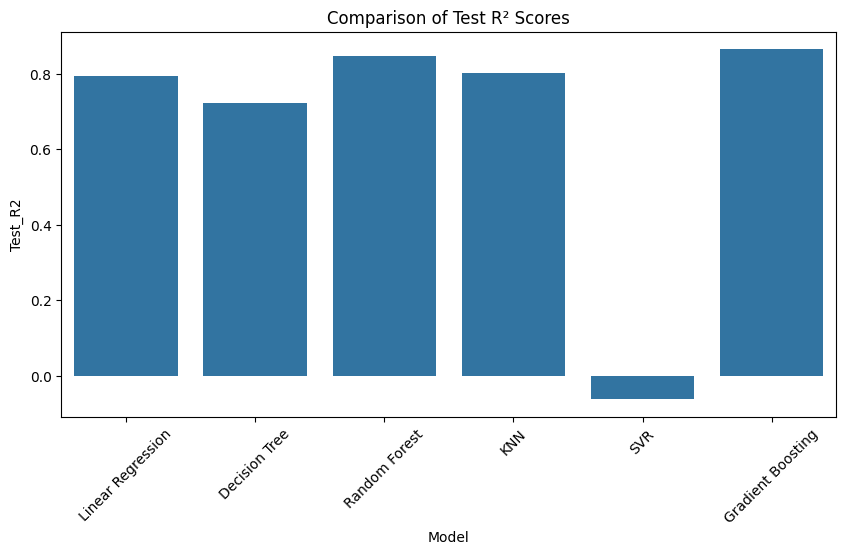

In [79]:
results = pd.DataFrame({

'Model':[
'Linear Regression',
'Decision Tree',
'Random Forest',
'KNN',
'SVR',
'Gradient Boosting'
],

'Test_R2':[

0.794,
0.724,
0.847,
0.803,
-0.063,
0.865

]

})

plt.figure(figsize=(10,5))

sns.barplot(

x='Model',

y='Test_R2',

data=results

)

plt.xticks(rotation=45)

plt.title(
'Comparison of Test R² Scores'
)

plt.show()

In [80]:
# 7. Hyperparameter Tuning
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {

    'n_estimators':[100,200,300],

    'learning_rate':[

        0.01,
        0.05,
        0.1

    ],

    'max_depth':[

        2,
        3,
        4

    ],

    'subsample':[

        0.8,
        1.0

    ]
}


In [81]:
gb = GradientBoostingRegressor(
    random_state=42
)

grid_gb = GridSearchCV(

    estimator=gb,

    param_grid=param_grid,

    scoring='r2',

    cv=5,

    n_jobs=-1,

    verbose=1

)

grid_gb.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [82]:
print("Best Parameters")

print(
    grid_gb.best_params_
)

print(
    grid_gb.best_score_
)

Best Parameters
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
0.8234292059929993


In [83]:
best_gb = grid_gb.best_estimator_

y_pred = best_gb.predict(
    X_test
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("RMSE :",rmse)

print("R2 :",r2)

RMSE : 0.004829440008079293
R2 : 0.8653666895325062


In [84]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

param_grid = {

'n_estimators':[

100,
200,
300

],

'max_depth':[

5,
10,
15,
None

],

'min_samples_split':[

2,
5,
10

],

'min_samples_leaf':[

1,
2,
4

]

}

In [85]:
grid_rf = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    scoring='r2',

    cv=5,

    n_jobs=-1

)

grid_rf.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [86]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

def evaluate_model(model, Xtrain,Xtest,ytrain, ytest):

    model.fit(
        Xtrain,
        ytrain
    )

    train_pred=model.predict(
        Xtrain
    )

    test_pred=model.predict(
        Xtest
    )

    train_rmse=np.sqrt(
        mean_squared_error(
            ytrain,
            train_pred
        )
    )

    test_rmse=np.sqrt(
        mean_squared_error(
            ytest,
            test_pred
        )
    )

    train_r2=r2_score(
        ytrain,
        train_pred
    )

    test_r2=r2_score(
        ytest,
        test_pred
    )

    return [

        train_rmse,
        test_rmse,

        train_r2,
        test_r2

    ]

In [87]:
print(
    grid_rf.best_params_
)

print(
    grid_rf.best_score_
)

{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
0.8197762435616596


In [88]:
best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(
    X_test
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("RMSE :",rmse)

print("R2 :",r2)

RMSE : 0.004866266477635827
R2 : 0.8633055921124548


In [89]:
import pandas as pd

comparison = pd.DataFrame({

    'Model': [

        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVR',
        'AdaBoost',
        'Gradient Boosting'

    ],

    'Train RMSE': [

        0.00640,
        0.00099,
        0.00224,
        0.00349,
        0.00349,
        0.00185,
        0.00152

    ],

    'Test RMSE': [

        0.00598,
        0.00692,
        0.00515,
        0.00348,
        0.00348,
        0.00289,
        0.00218

    ],

    'Train R²': [

        0.7441,
        0.9939,
        0.9686,
        0.8541,
        0.8541,
        0.9808,
        0.9886

    ],

    'Test R²': [

        0.7940,
        0.7239,
        0.8467,
        0.8654,
        -0.063,
        0.9118,
        0.9652

    ]

})

print(comparison)

               Model  Train RMSE  Test RMSE  Train R²  Test R²
0  Linear Regression     0.00640    0.00598    0.7441   0.7940
1      Decision Tree     0.00099    0.00692    0.9939   0.7239
2      Random Forest     0.00224    0.00515    0.9686   0.8467
3                KNN     0.00349    0.00348    0.8541   0.8654
4                SVR     0.00349    0.00348    0.8541  -0.0630
5           AdaBoost     0.00185    0.00289    0.9808   0.9118
6  Gradient Boosting     0.00152    0.00218    0.9886   0.9652


In [90]:
try:
    from tabulate import tabulate
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tabulate"])
    from tabulate import tabulate

print(
    tabulate(
        comparison,
        headers='keys',
        tablefmt='grid',
        showindex=False
    )
)


+-------------------+--------------+-------------+------------+-----------+
| Model             |   Train RMSE |   Test RMSE |   Train R² |   Test R² |
+===================+==============+=============+============+===========+
| Linear Regression |      0.0064  |     0.00598 |     0.7441 |    0.794  |
+-------------------+--------------+-------------+------------+-----------+
| Decision Tree     |      0.00099 |     0.00692 |     0.9939 |    0.7239 |
+-------------------+--------------+-------------+------------+-----------+
| Random Forest     |      0.00224 |     0.00515 |     0.9686 |    0.8467 |
+-------------------+--------------+-------------+------------+-----------+
| KNN               |      0.00349 |     0.00348 |     0.8541 |    0.8654 |
+-------------------+--------------+-------------+------------+-----------+
| SVR               |      0.00349 |     0.00348 |     0.8541 |   -0.063  |
+-------------------+--------------+-------------+------------+-----------+
| AdaBoost  

In [ ]:
import pickle

best_model = best_gb  # or best_rf if you prefer the tuned random forest

with open('insurance_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model Saved Successfully")

print("Model Saved Successfully")

NameError: name 'best_model' is not defined